# Klasifikasi Tangisan Bayi
Pendekatan yang dipakai di notebook ini:

| Aspek | Keputusan |
|---|---|
| **Unit data** | **1 video = 1 sample** (beberapa frame diringkas jadi 1 vektor fitur, bukan dijadikan baris data terpisah) |
| **Cabang citra** | **Transfer learning** — backbone pretrained ImageNet yang dibekukan, hanya layer proyeksi kecil di atasnya yang dilatih |
| **Pooling antar-frame** | `POOLING = 'mean'` (rata-rata) atau `'attention'` (bobot antar frame dipelajari model) |
| **Cabang audio** | CNN kecil dilatih dari nol, input **array log-mel mentah** (`.npy`, bukan gambar berwarna/PNG) |
| **Titik fusi** | `Concatenate` di level fitur → **intermediate / feature-level fusion** |
| **Split** | 3 arah **test diambil langsung dari folder `data_test_video`** (bukan hasil pecahan acak), sisanya dipecah stratified-group jadi train/val |


In [22]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import tensorflow as tf
from pathlib import Path
from moviepy import VideoFileClip
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## Konfigurasi

In [23]:
VIDEO_DIR = 'Data_Video_Bayi'
WORK_DIR  = 'work'
FRAME_DIR = os.path.join(WORK_DIR, 'frames')
SPEC_DIR  = os.path.join(WORK_DIR, 'spectrograms')

BACKBONE = 'resnet18'
POOLING  = 'mean'
FRAME_SIZE = (224, 224)
N_CHANNELS = 3

SPEC_SIZE     = (64, 128)
SPEC_CHANNELS = 1

N_FRAMES_PER_VIDEO = 5
AUDIO_DURATION = 4.0
BATCH_SIZE = 64
UPDATES_PER_EPOCH = 12
EPOCHS     = 100
SEED       = 42

TRAIN_DIR_NAMES = ['data_train_video']
TEST_DIR_NAMES  = ['data_test_video']

CLASS_NAMES = ['eairh', 'eh', 'heh', 'neh', 'owh']
N_CLASSES   = len(CLASS_NAMES)

MEANINGS = {'eairh': 'Tidak nyaman perut bawah', 'eh': 'Perlu bersendawa',
            'heh': 'Tidak nyaman', 'neh': 'Lapar', 'owh': 'Mengantuk'}

RESULTS_DIR = 'results'

for d in [FRAME_DIR, SPEC_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)

### ResNet18

In [24]:
if BACKBONE == 'resnet18':
    try:
        from classification_models.tfkeras import Classifiers
    except ImportError:
        import sys, subprocess
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'image-classifiers==1.0.0'], check=True)
        from classification_models.tfkeras import Classifiers
    ResNet18, resnet18_preprocess = Classifiers.get('resnet18')
    print("ResNet18 (image-classifiers) siap dipakai.")


ResNet18 (image-classifiers) siap dipakai.


## Ekstraksi dari video

In [25]:
def extract_video_sample(video_path, frame_prefix, spec_prefix, n_frames=N_FRAMES_PER_VIDEO, frame_size=FRAME_SIZE):
    try:
        clip = VideoFileClip(video_path)
        audio = clip.audio
    except Exception as e:
        print(f"  Gagal load video: {Path(video_path).name} ({e})")
        return None
    if audio is None:
        clip.close()
        return None

    tmp_wav = f"{spec_prefix}_tmp.wav"
    audio.write_audiofile(tmp_wav, logger=None)
    clip.close()

    X, sr = librosa.load(tmp_wav, sr=None, res_type='kaiser_fast')
    os.remove(tmp_wav)
    if X.size == 0:
        return None

    max_len = int(AUDIO_DURATION * sr)
    if len(X) > max_len:
        X = X[:max_len]

    S = librosa.feature.melspectrogram(y=X, sr=sr, n_mels=SPEC_SIZE[0])
    S_db = librosa.power_to_db(S, ref=np.max)
    S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)

    S_resized = cv2.resize(S_db.astype(np.float32), (SPEC_SIZE[1], SPEC_SIZE[0]),
                           interpolation=cv2.INTER_LINEAR)
    spec_out = f"{spec_prefix}.npy"
    np.save(spec_out, np.flipud(S_resized).copy())

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total / fps if fps > 0 else 0

    frame_paths = []
    for i in range(n_frames):
        target = duration * (i + 0.5) / n_frames if duration > 0 else 0.0
        cap.set(cv2.CAP_PROP_POS_MSEC, target * 1000)
        ok, frame = cap.read()
        if not ok:
            break
        out = f"{frame_prefix}_f{i}.png"
        plt.imsave(out, cv2.cvtColor(cv2.resize(frame, frame_size), cv2.COLOR_BGR2RGB))
        frame_paths.append(out)
    cap.release()

    if not frame_paths:
        return None

    n_valid = len(frame_paths)
    if n_valid < n_frames:
        blank_path = f"{frame_prefix}_pad.png"
        plt.imsave(blank_path, np.zeros((frame_size[1], frame_size[0], 3), dtype=np.uint8))
        frame_paths += [blank_path] * (n_frames - n_valid)

    frame_mask = [1.0] * n_valid + [0.0] * (n_frames - n_valid)
    return frame_paths, spec_out, frame_mask


In [26]:
VIDEO_EXTENSIONS = ('.mp4', '.mov', '.avi', '.mkv')

def list_videos(class_dir, dir_names):
    found = []
    for name in dir_names:
        d = class_dir / name
        if d.is_dir():
            found += [p for p in d.glob('*') if p.suffix.lower() in VIDEO_EXTENSIONS]
    return found

samples = []

for class_name in CLASS_NAMES:
    class_dir = Path(VIDEO_DIR) / class_name
    if not class_dir.is_dir():
        print(f"Lewati (folder tidak ada): {class_dir}")
        continue

    train_videos = list_videos(class_dir, TRAIN_DIR_NAMES)
    test_videos  = list_videos(class_dir, TEST_DIR_NAMES)
    print(f"{class_name}: {len(train_videos)} video di folder train, {len(test_videos)} video di folder test")

    for origin, video_paths in [('trainval', train_videos), ('test', test_videos)]:
        for video_path in video_paths:
            stem = video_path.stem
            result = extract_video_sample(
                str(video_path),
                os.path.join(FRAME_DIR, f"{class_name}_{stem}"),
                os.path.join(SPEC_DIR, f"{class_name}_{stem}"),
            )
            if result is None:
                continue
            frame_paths, spec_path, frame_mask = result
            samples.append({'frame_paths': frame_paths, 'spec_path': spec_path,
                            'frame_mask': frame_mask,
                            'label': CLASS_NAMES.index(class_name),
                            'video_id': f"{class_name}_{stem}",
                            'origin': origin,
                            'source_path': str(video_path)})

df_samples = pd.DataFrame(samples)
print(f"\nTotal: {len(df_samples)} video = {len(df_samples)} sample\n")
print(pd.crosstab(df_samples['label'].map(dict(enumerate(CLASS_NAMES))), df_samples['origin']))

eairh: 28 video di folder train, 7 video di folder test
eh: 28 video di folder train, 7 video di folder test
heh: 28 video di folder train, 7 video di folder test
neh: 28 video di folder train, 7 video di folder test
owh: 28 video di folder train, 7 video di folder test

Total: 175 video = 175 sample

origin  test  trainval
label                 
eairh      7        28
eh         7        28
heh        7        28
neh        7        28
owh        7        28


### Periksa hasil ekstraksi secara visual

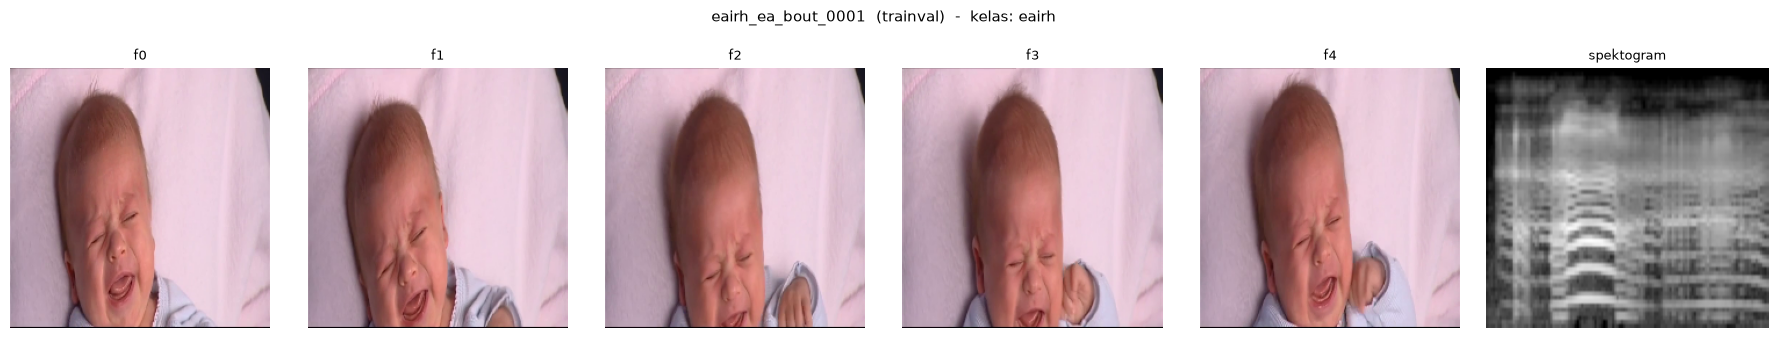

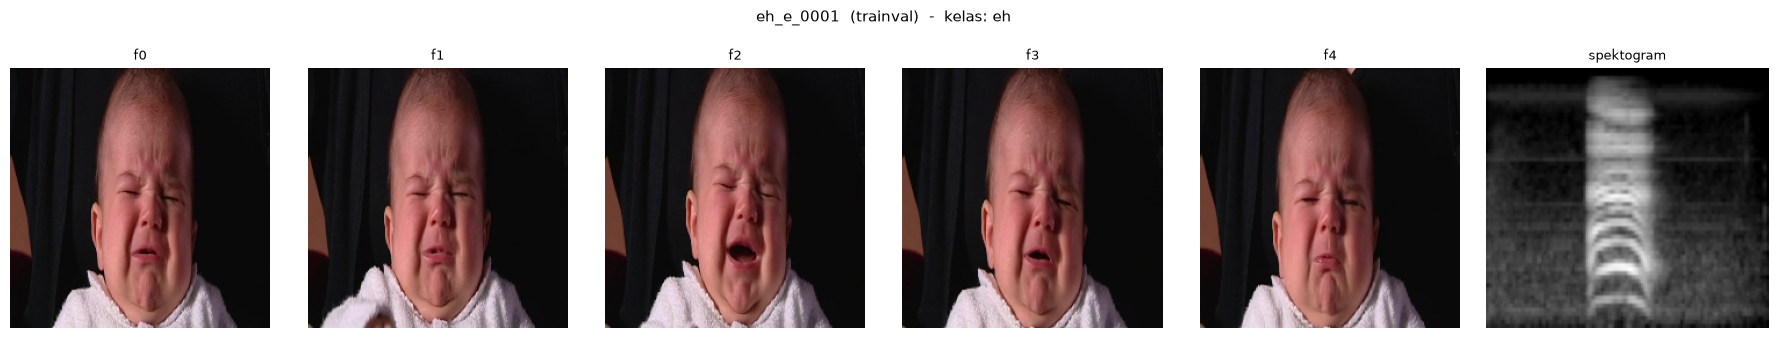

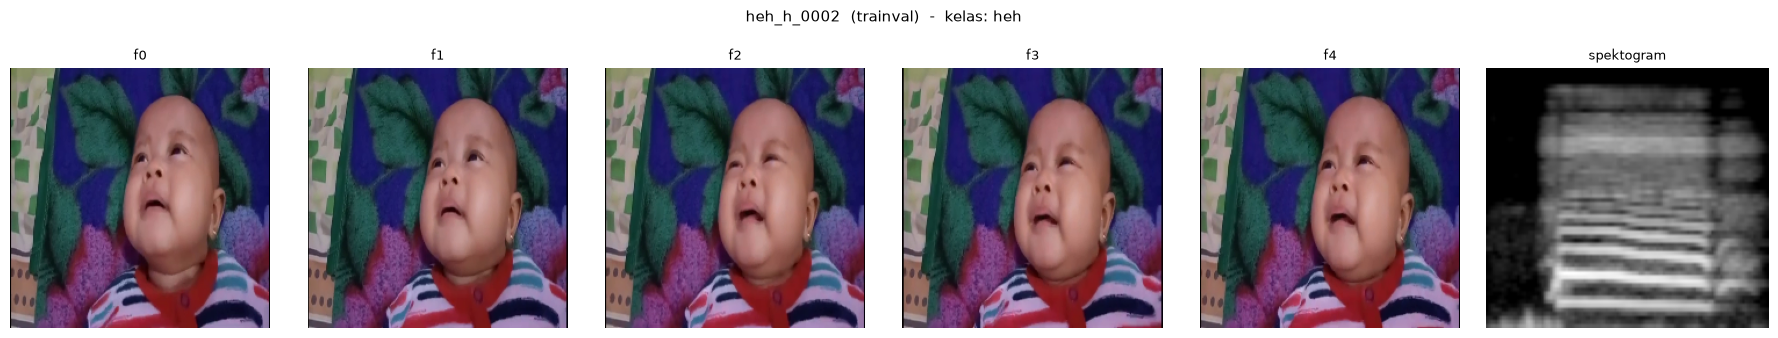

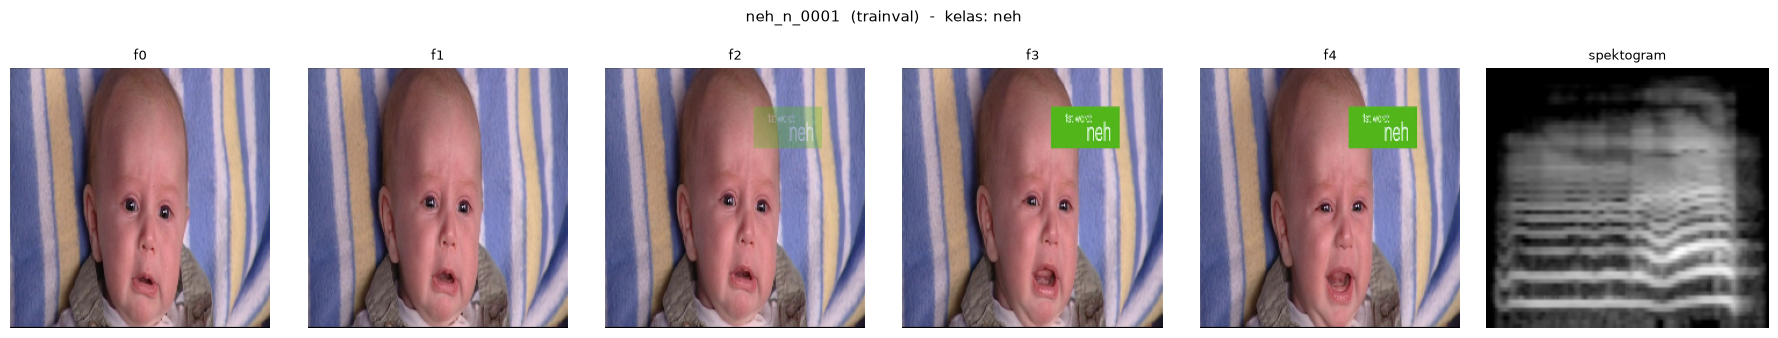

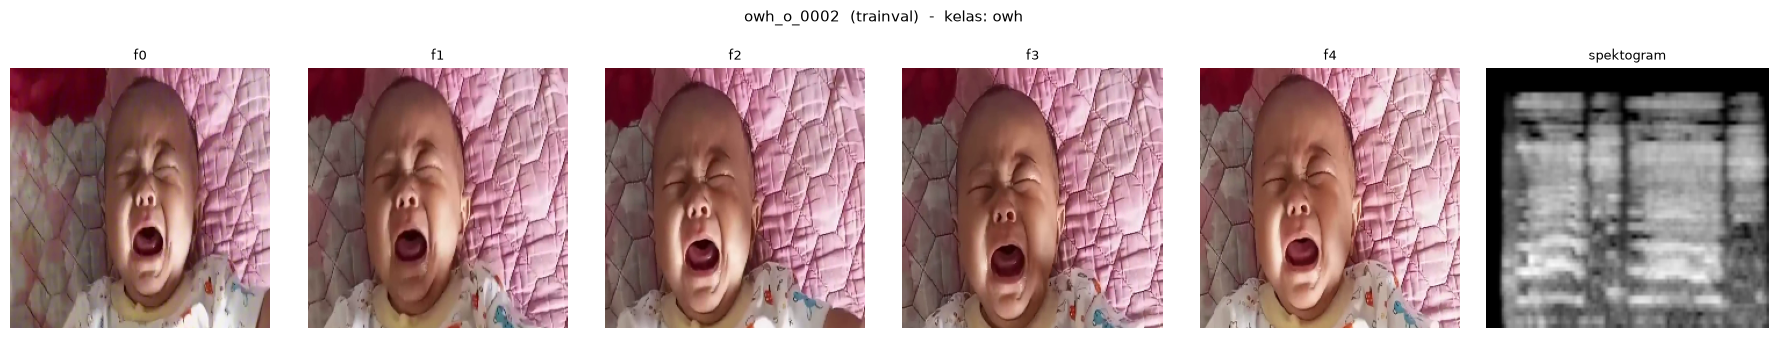

In [27]:
def preview_sample(row):
    n = len(row['frame_paths'])
    fig, axes = plt.subplots(1, n + 1, figsize=(3 * (n + 1), 3.4))
    for i, p in enumerate(row['frame_paths']):
        axes[i].imshow(plt.imread(p))
        is_pad = row['frame_mask'][i] == 0 
        axes[i].set_title(f"f{i}" + (" (pad)" if is_pad else ""), fontsize=9,
                          color='red' if is_pad else 'black')
        axes[i].axis('off')

    spec_array = np.load(row['spec_path'])
    axes[-1].imshow(spec_array, cmap='gray', aspect='auto')
    axes[-1].set_title('spektogram', fontsize=9)
    axes[-1].axis('off')

    fig.suptitle(f"{row['video_id']}  ({row['origin']})  -  kelas: {CLASS_NAMES[row['label']]}", fontsize=11)
    plt.tight_layout(); plt.show()

# Tampilkan satu contoh dari tiap kelas
for label in range(N_CLASSES):
    subset = df_samples[df_samples['label'] == label]
    if len(subset):
        preview_sample(subset.iloc[0])


## Split train / val / test

In [28]:
from sklearn.model_selection import GroupShuffleSplit

def group_split(df, test_size, seed):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_a, idx_b = next(splitter.split(df, groups=df['video_id']))
    return df.iloc[idx_a], df.iloc[idx_b]

def stratified_group_split(df, test_size, seed):
    parts_a, parts_b = [], []
    for label in sorted(df['label'].unique()):
        subset = df[df['label'] == label]
        a, b = group_split(subset, test_size=test_size, seed=seed)
        parts_a.append(a); parts_b.append(b)
    return pd.concat(parts_a).reset_index(drop=True), pd.concat(parts_b).reset_index(drop=True)

# test_df langsung dari folder data_test_video
test_df     = df_samples[df_samples['origin'] == 'test'].reset_index(drop=True)
trainval_df = df_samples[df_samples['origin'] == 'trainval'].reset_index(drop=True)

train_df, valid_df = stratified_group_split(trainval_df, test_size=0.2, seed=SEED)

for name, d in [('Train', train_df), ('Valid', valid_df), ('Test ', test_df)]:
    dist = d['label'].value_counts().sort_index().tolist()
    print(f"{name}: {len(d):3d} video   distribusi per kelas {dict(zip(CLASS_NAMES, dist))}")

Train: 110 video   distribusi per kelas {'eairh': 22, 'eh': 22, 'heh': 22, 'neh': 22, 'owh': 22}
Valid:  30 video   distribusi per kelas {'eairh': 6, 'eh': 6, 'heh': 6, 'neh': 6, 'owh': 6}
Test :  35 video   distribusi per kelas {'eairh': 7, 'eh': 7, 'heh': 7, 'neh': 7, 'owh': 7}


## Pipeline data

In [29]:
if BACKBONE == 'mobilenet':
    PREPROCESS = tf.keras.applications.mobilenet_v2.preprocess_input
elif BACKBONE == 'resnet18':
    PREPROCESS = resnet18_preprocess
else:
    PREPROCESS = tf.keras.applications.resnet50.preprocess_input

def load_frame(path):
    img = tf.image.decode_png(tf.io.read_file(path), channels=N_CHANNELS)
    img = tf.image.resize(img, FRAME_SIZE)
    return PREPROCESS(img)

def load_spec(path):
    def _load(p):
        arr = np.load(p.numpy().decode('utf-8')).astype(np.float32)
        return arr[..., np.newaxis]
    spec = tf.py_function(func=_load, inp=[path], Tout=tf.float32)
    spec.set_shape([*SPEC_SIZE, SPEC_CHANNELS])
    return spec

def spec_augment(img, max_mask_frac=0.0):
    h, w = tf.shape(img)[0], tf.shape(img)[1]
    max_f = tf.maximum(tf.cast(tf.cast(h, tf.float32) * max_mask_frac, tf.int32), 1)
    max_t = tf.maximum(tf.cast(tf.cast(w, tf.float32) * max_mask_frac, tf.int32), 1)

    f  = tf.random.uniform([], 0, max_f, dtype=tf.int32)
    f0 = tf.random.uniform([], 0, tf.maximum(h - f, 1), dtype=tf.int32)
    img = img * tf.reshape(tf.concat([tf.ones([f0]), tf.zeros([f]), tf.ones([h - f0 - f])], 0), [h, 1, 1])

    t  = tf.random.uniform([], 0, max_t, dtype=tf.int32)
    t0 = tf.random.uniform([], 0, tf.maximum(w - t, 1), dtype=tf.int32)
    img = img * tf.reshape(tf.concat([tf.ones([t0]), tf.zeros([t]), tf.ones([w - t0 - t])], 0), [1, w, 1])
    return img

def make_dataset(df, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((
        np.stack(df['frame_paths'].values),
        df['spec_path'].values,
        np.stack(df['frame_mask'].values).astype('float32'),
        df['label'].values,
    ))

    def _load(frame_paths, spec_path, mask, label):
        frames = tf.map_fn(load_frame, frame_paths, fn_output_signature=tf.float32)
        return (frames, load_spec(spec_path), mask), label

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        flip = tf.keras.layers.RandomFlip("horizontal")
        def _aug(x, y):
            frames, spec, mask = x
            return (flip(frames, training=True), spec_augment(spec), mask), y
        ds = ds.map(_aug, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset = make_dataset(train_df, shuffle=True, augment=True).repeat()
valid_dataset = make_dataset(valid_df)
test_dataset  = make_dataset(test_df)

STEPS_PER_EPOCH = UPDATES_PER_EPOCH

## Model

**Cabang citra** memakai backbone pretrained yang dibekukan. Backbone yang sama diterapkan ke setiap
frame lewat `TimeDistributed`. Fitur antar-frame diringkas jadi satu vektor lewat salah satu dari 2 cara
(diatur oleh `POOLING` di sel konfigurasi):

- `'mean'` = rata-rata biasa antar-frame, tiap frame dianggap sama penting.
- `'attention'` = bobot antar-frame **dipelajari model** (skor kecil per frame -> softmax), jadi
  frame yang lebih informatif (misal ekspresi wajah bayi lebih jelas) otomatis dapat bobot lebih besar.

**Cabang audio** adalah CNN kecil yang dilatih dari nol, menerima array log-mel mentah (bukan gambar).

Kedua fitur diproyeksikan ke 128 dimensi, digabung menjadi 256, lalu masuk ke classifier bersama.


In [30]:
if BACKBONE == 'mobilenet':
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=(*FRAME_SIZE, N_CHANNELS), include_top=False, weights='imagenet', pooling='avg')
elif BACKBONE == 'resnet18':
    _resnet18_base = ResNet18(input_shape=(*FRAME_SIZE, N_CHANNELS), include_top=False, weights='imagenet')
    backbone = tf.keras.Sequential(
        [_resnet18_base, tf.keras.layers.GlobalAveragePooling2D()], name='resnet18_backbone')
else:
    backbone = tf.keras.applications.ResNet50(
        input_shape=(*FRAME_SIZE, N_CHANNELS), include_top=False, weights='imagenet', pooling='avg')

# def se_block(input_tensor, reduction_ratio=16):
#     channel_axis = -1
#     filters = input_tensor.shape[channel_axis]
#     se_shape = (1, 1, filters)
    
#     se = tf.keras.layers.GlobalAveragePooling2D()(input_tensor)
#     se = tf.keras.layers.Reshape(se_shape)(se)
#     se = tf.keras.layers.Dense(filters // reduction_ratio, activation='relu')(se)
#     se = tf.keras.layers.Dense(filters, activation='sigmoid')(se)
    
#     return tf.keras.layers.multiply([input_tensor, se])

backbone.trainable = False          # dibekukan: tidak ikut dilatih, hanya jadi pengekstrak fitur
print(f"Backbone: {backbone.name}, dimensi fitur: {backbone.output_shape[-1]}")

input_frames = tf.keras.layers.Input(shape=(N_FRAMES_PER_VIDEO, *FRAME_SIZE, N_CHANNELS),
                                     name='input_citra')
input_mask   = tf.keras.layers.Input(shape=(N_FRAMES_PER_VIDEO,), name='input_mask')
mask_expanded = tf.keras.layers.Reshape((N_FRAMES_PER_VIDEO, 1), name='mask_reshape')(input_mask)

per_frame = tf.keras.layers.TimeDistributed(backbone, name='backbone_per_frame')(input_frames)

if POOLING == 'attention':
    attn_hidden = tf.keras.layers.Dense(32, activation='tanh', name='attn_hidden')(per_frame)
    attn_score  = tf.keras.layers.Dense(1, name='attn_score')(attn_hidden)
    neg_bias    = tf.keras.layers.Lambda(lambda m: (1.0 - m) * -1e9, name='mask_bias')(mask_expanded)
    attn_score  = tf.keras.layers.Add(name='attn_score_masked')([attn_score, neg_bias])
    attn_weight = tf.keras.layers.Softmax(axis=1, name='attn_softmax')(attn_score)
    weighted    = tf.keras.layers.Multiply(name='attn_weighted')([per_frame, attn_weight])
    pooled_frame = tf.keras.layers.Lambda(lambda x: tf.reduce_sum(x, axis=1), name='attn_sum')(weighted)
else:
    masked_sum  = tf.keras.layers.Lambda(lambda x: tf.reduce_sum(x[0] * x[1], axis=1),
                                         name='masked_sum')([per_frame, mask_expanded])
    valid_count = tf.keras.layers.Lambda(lambda m: tf.reduce_sum(m, axis=1) + 1e-6,
                                         name='valid_count')(mask_expanded)
    pooled_frame = tf.keras.layers.Lambda(lambda x: x[0] / x[1], name='masked_mean')([masked_sum, valid_count])

# feat_citra = tf.keras.layers.LayerNormalization(name='citra_norm')(pooled_frame)
# feat_citra = tf.keras.layers.Dense(512, activation='relu', name='citra_proyeksi')(feat_citra)
     
# Cabang audio
input_spec = tf.keras.layers.Input(shape=(*SPEC_SIZE, SPEC_CHANNELS), name='input_audio')
x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(input_spec)
x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = tf.keras.layers.Dropout(0.5)(x)

x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = tf.keras.layers.Dropout(0.5)(x)

x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
# x = se_block(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)

# feat_audio = tf.keras.layers.Dense(512, activation='relu', name='audio_proyeksi')(x)
# feat_audio = tf.keras.layers.Dropout(0.5)(feat_audio)

# Fusi intermediate
fused = tf.keras.layers.Concatenate(name='fusi_intermediate')([feat_citra, feat_audio])
head = tf.keras.layers.Dropout(0.5)(fused)
output = tf.keras.layers.Dense(N_CLASSES, activation='softmax', name='hasil_prediksi')(head)

model = tf.keras.Model([input_frames, input_spec, input_mask], output, name='intermediate_fusion')

trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
frozen    = sum(np.prod(w.shape) for w in model.non_trainable_weights)
print(f"Parameter dilatih: {trainable:,}  |  dibekukan: {frozen:,}")

model.summary()

Backbone: resnet18_backbone, dimensi fitur: 512
Parameter dilatih: 770,053  |  dibekukan: 11,186,889


Model: "intermediate_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_audio         │ (None, 64, 128,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 128,   │        640 │ input_audio[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 64,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32, 64,    │          0 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 64,    │     73,856 │ dropout_9[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 32,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_citra         │ (None, 5, 224,    │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_mask          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 16, 32,    │          0 │ max_pooling2d_5[… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_per_frame  │ (None, 5, 512)    │ 11,186,889 │ input_citra[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_reshape        │ (None, 5, 1)      │          0 │ input_mask[0][0]  │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 32,    │    295,168 │ dropout_10[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_sum (Lambda) │ (None, 512)       │          0 │ backbone_per_fra… │
│                     │                   │            │ mask_reshape[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ valid_count         │ (None, 1)         │          0 │ mask_reshape[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv2d_8[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_mean         │ (None, 512)       │          0 │ masked_sum[0][0], │
│ (Lambda)            │                   │            │ valid_count[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 256)       │          0 │ global_average_p

 Total params: 11,956,942 (45.61 MB)

 Trainable params: 770,053 (2.94 MB)

 Non-trainable params: 11,186,889 (42.67 MB)

## Training

In [ ]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=0.01),
    metrics=['accuracy'],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

history = model.fit(train_dataset, epochs=EPOCHS, steps_per_epoch=STEPS_PER_EPOCH,
                    validation_data=valid_dataset, callbacks=callbacks)

Epoch 1/100


c:\Projek\Madsaz-Dio\Model\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


12/12 ━━━━━━━━━━━━━━━━━━━━ 77s 5s/step - accuracy: 0.3030 - loss: 1.6413 - val_accuracy: 0.4000 - val_loss: 1.3842 - learning_rate: 1.0000e-04
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.4242 - loss: 1.3854 - val_accuracy: 0.5667 - val_loss: 1.2843 - learning_rate: 1.0000e-04
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.5500 - loss: 1.1728 - val_accuracy: 0.6333 - val_loss: 1.2128 - learning_rate: 1.0000e-04
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.6758 - loss: 0.9863 - val_accuracy: 0.6000 - val_loss: 1.1482 - learning_rate: 1.0000e-04
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.7167 - loss: 0.8922 - val_accuracy: 0.6667 - val_loss: 1.0921 - learning_rate: 1.0000e-04
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.7652 - loss: 0.7813 - val_accuracy: 0.7000 - val_loss: 1.0431 - learning_rate: 1.0000e-04
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.8091 - loss: 0.71

## Kurva training

Tersimpan: results\training_curves.png


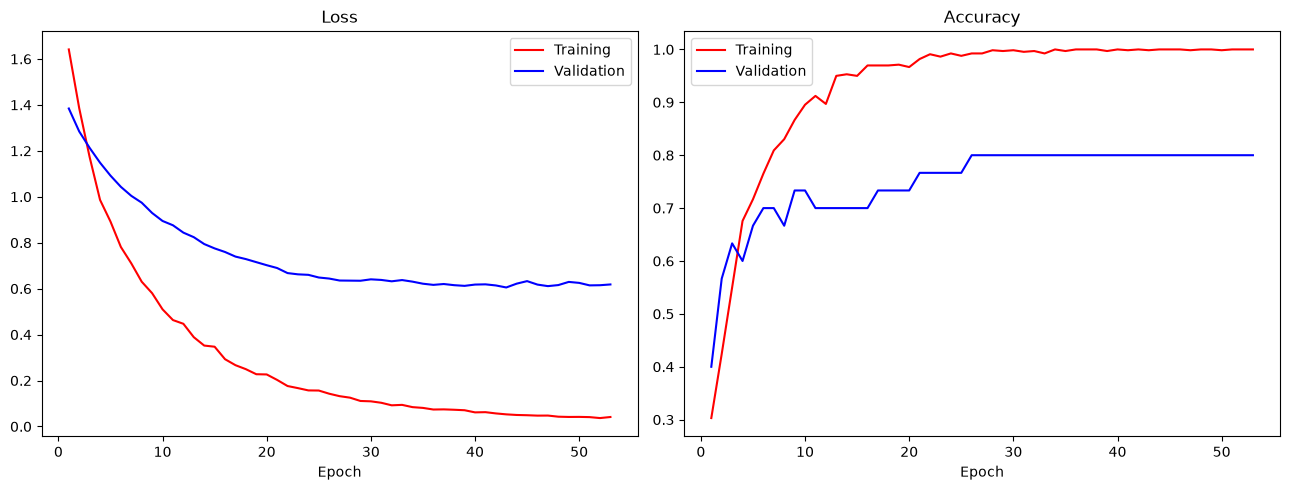

In [32]:
h = history.history
ep = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(ep, h['loss'], 'r', label='Training')
axes[0].plot(ep, h['val_loss'], 'b', label='Validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(ep, h['accuracy'], 'r', label='Training')
axes[1].plot(ep, h['val_accuracy'], 'b', label='Validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()

save_path = os.path.join(RESULTS_DIR, 'training_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Tersimpan: {save_path}")

plt.show()


## Evaluasi pada validation

Tersimpan: results\confusion_matrix_validation.png


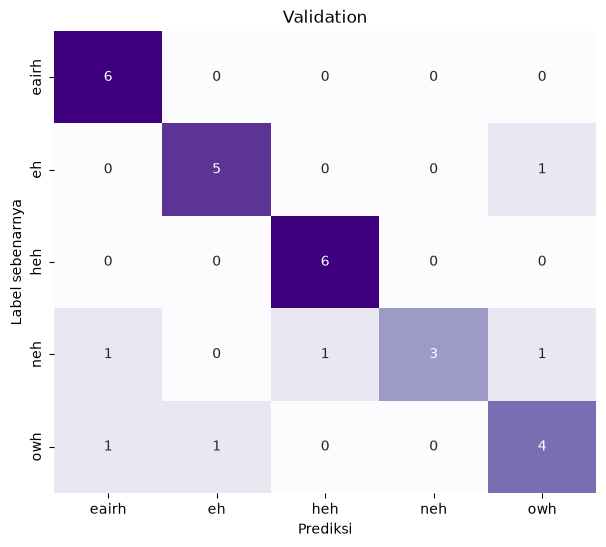

              precision    recall  f1-score   support

       eairh     0.7500    1.0000    0.8571         6
          eh     0.8333    0.8333    0.8333         6
         heh     0.8571    1.0000    0.9231         6
         neh     1.0000    0.5000    0.6667         6
         owh     0.6667    0.6667    0.6667         6

    accuracy                         0.8000        30
   macro avg     0.8214    0.8000    0.7894        30
weighted avg     0.8214    0.8000    0.7894        30

Accuracy : 0.8000
Macro F1 : 0.7894
Tersimpan: results\confusion_matrix_validation.txt


In [33]:
def report(dataset, df, judul, cmap, save_name):
    y_true = df['label'].values
    y_pred = np.argmax(model.predict(dataset, verbose=0), axis=1)

    plt.figure(figsize=(7, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cbar=False, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.ylabel('Label sebenarnya'); plt.xlabel('Prediksi'); plt.title(judul)

    png_path = os.path.join(RESULTS_DIR, f'{save_name}.png')
    plt.savefig(png_path, dpi=150, bbox_inches='tight')
    print(f"Tersimpan: {png_path}")
    plt.show()

    report_text = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                        digits=4, zero_division=0)
    acc = (y_true == y_pred).mean()
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(report_text)
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")

    txt_path = os.path.join(RESULTS_DIR, f'{save_name}.txt')
    with open(txt_path, 'w') as f:
        f.write(f"{judul}\n\n")
        f.write(report_text)
        f.write(f"\nAccuracy : {acc:.4f}\n")
        f.write(f"Macro F1 : {macro_f1:.4f}\n")
    print(f"Tersimpan: {txt_path}")

report(valid_dataset, valid_df, 'Validation', 'Purples', save_name='confusion_matrix_validation')


## Evaluasi TEST SET

**Aturan: test set hanya boleh dievaluasi SEKALI per model final.** Kalau hasilnya sudah pernah
tersimpan di `results/`, sel di bawah menolak menjalankan ulang


Tersimpan: results\confusion_matrix_test.png


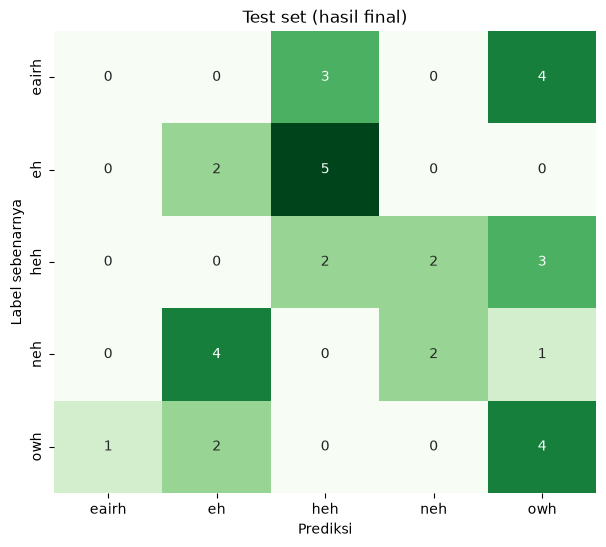

              precision    recall  f1-score   support

       eairh     0.0000    0.0000    0.0000         7
          eh     0.2500    0.2857    0.2667         7
         heh     0.2000    0.2857    0.2353         7
         neh     0.5000    0.2857    0.3636         7
         owh     0.3333    0.5714    0.4211         7

    accuracy                         0.2857        35
   macro avg     0.2567    0.2857    0.2573        35
weighted avg     0.2567    0.2857    0.2573        35

Accuracy : 0.2857
Macro F1 : 0.2573
Tersimpan: results\confusion_matrix_test.txt


In [34]:
# [FIX] Guard anti re-run: tolak mengevaluasi ulang test set kalau hasilnya sudah pernah disimpan.
_test_result_path = os.path.join(RESULTS_DIR, 'confusion_matrix_test.txt')
if os.path.exists(_test_result_path):
    raise FileExistsError(
        f"'{_test_result_path}' sudah ada -- test set sudah pernah dievaluasi untuk run ini.\n"
        "Hapus file itu secara sengaja dulu kalau memang mau evaluasi ulang (misal setelah retrain)."
    )

report(test_dataset, test_df, 'Test set (hasil final)', 'Greens', save_name='confusion_matrix_test')


## Simpan model & inferensi video baru

In [35]:
model.save('tangis_bayi_fusion.keras')

def predict_video(video_path):
    result = extract_video_sample(
        video_path,
        os.path.join(WORK_DIR, 'infer_frame'),
        os.path.join(WORK_DIR, 'infer_spec'),
    )
    if result is None:
        raise ValueError("Gagal mengekstrak citra/audio dari video ini.")
    frame_paths, spec_path, frame_mask = result

    frames = tf.expand_dims(tf.stack([load_frame(p) for p in frame_paths]), 0)
    spec   = tf.expand_dims(load_spec(spec_path), 0)
    mask   = tf.expand_dims(tf.constant(frame_mask, dtype=tf.float32), 0)   # [BARU]

    probs = model.predict([frames, spec, mask], verbose=0)[0]
    for cls, p in sorted(zip(CLASS_NAMES, probs), key=lambda kv: -kv[1]):
        print(f"  {cls:6s} ({MEANINGS[cls]:26s}) : {p:.4f}")
    hasil = CLASS_NAMES[int(np.argmax(probs))]
    print(f"\nPrediksi: {hasil} — {MEANINGS[hasil]}")
    return hasil

predict_video('data_test_video/tes.mp4')

  heh    (Tidak nyaman              ) : 0.9642
  eairh  (Tidak nyaman perut bawah  ) : 0.0260
  neh    (Lapar                     ) : 0.0056
  eh     (Perlu bersendawa          ) : 0.0031
  owh    (Mengantuk                 ) : 0.0011

Prediksi: heh — Tidak nyaman


'heh'